In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
# data source: https://www.microdata.statistics.gov.rw/index.php/catalog/120
df = pd.read_stata('FinScope_2024_Rwanda.dta') #reading the data from the stata file into a pandas dataframe

The general objective of this project is to use ML to study financial inclusion in Rwanda. to predict how included a person is financially (whether s/he has a bank account, use mobile money, save only informally, or has no access at all), and to find natural groups among people based on their financial behavior

the reason i chose this topic is because I am interested in fintech, and financial inclusion is one of the biggest topics in Rwanda since the roll-out of e-kash. Even though almost everyone in Rwanda now has some form of financial access, mostly through mobile money, many people still do not have a bank account or rely only on informal ways to save and borrow like cooperatives (Ikibina). I want to understand what kind of people are more likely to be left in these weaker levels of access, since this could help show where financial services are still needed most.

In [3]:
df.head()

,key,a1,a2,a6,hh_wt,pop_wt,hh_size,hh_head,bo,b1,...,d1c11,d1a13,d1b13,d1c13,d1a14,d1b14,d1c14,d1a15,d1b15,d1c15
0,11838,East,Gatsibo,Rural,519.583516,1168.281635,5,male,Household head,60,...,Walk,Between 3Km and 5Km,Don?t know,Walk,Less than 500m,Less than 15 minutes,Walk,Between 31 and 60 minutes,Between 3Km and 5Km,Walk
1,12132,East,Kayonza,Rural,367.836964,331.291150,5,male,Household head,55,...,Moto,Less than 500m,Less than 15 minutes,Moto,Less than 500m,Less than 15 minutes,Walk,Less than 15 minutes,Less than 500m,Moto
2,1328,Kigali,Kicukiro,Urban,258.755933,283.327154,4,male,Household head,33,...,Walk,Between 1Km and 2Km,Between 15 and 30 minutes,Walk,Less than 500m,Between 15 and 30 minutes,Walk,Between 15 and 30 minutes,Between 1Km and 2Km,Walk
3,11377,East,Nyagatare,Rural,369.340969,656.777371,1,male,Household head,76,...,Vehicle,More than 5Km,Between 15 and 30 minutes,Walk,Less than 500m,Less than 15 minutes,Walk,Between 31 and 60 minutes,Between 3Km and 5Km,Vehicle
4,10659,East,Rwamagana,Rural,256.832033,757.121752,5,male,Spouse/partner,53,...,NA,Between 3Km and 5Km,Don?t know,NA,Don?t know,Don?t know,NA,Don?t know,Don?t know,NA


In [4]:
df.shape

(13994, 2442)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13994 entries, 0 to 13993
Columns: 2442 entries, key to d1c15
dtypes: category(2249), float64(36), int16(1), int8(5), object(151)
memory usage: 50.4+ MB


In [6]:
reader = pd.io.stata.StataReader('FinScope_2024_Rwanda.dta')
labels = reader.variable_labels()
overview = pd.DataFrame({
    'column': df.columns,
    'label': [labels.get(c, '') for c in df.columns],
    'dtype': [str(df[c].dtype) for c in df.columns],
    'n_unique': [df[c].nunique() for c in df.columns],
    'pct_missing': [round(df[c].isna().mean() * 100, 1) for c in df.columns]
})

pd.set_option('display.max_rows', None)
overview

,column,label,dtype,n_unique,pct_missing
0,key,Household identifier,int16,13994,0.0
1,a1,A1. Province/Kigali City,category,5,0.0
2,a2,A2. District,category,30,0.0
3,a6,Urban_Rural,category,2,0.0
4,hh_wt,Household weight,float64,875,0.0
5,pop_wt,Individual weight_16+ years old,float64,11510,0.0
6,hh_size,household size,int8,10,0.0
7,hh_head,Sex of household head,category,2,0.0
8,bo,Relationship with the household head,category,7,0.0
9,b1,Age of respondent,int8,84,0.0


In [7]:
overview['pct_unique'] = overview['n_unique'] / len(df) * 100

id_like    = overview[overview['pct_unique'] > 95]
free_text  = overview[overview['label'].str.contains('specify', case=False, na=False)]  # open-ended — drop
weights    = overview[overview['column'].isin(['hh_wt', 'pop_wt'])]                  # keep aside, don't model on directly

high_missing = overview[overview['pct_missing'] > 45].sort_values('pct_missing', ascending=False)
print(high_missing[['column', 'label', 'pct_missing']].head(30))

         column                                              label  \
124         e20  Would like to know your opinions about these s...   
1075         h1   Do you agree/disagree with the following stat...   
53          e14  E14.Please tell me the level of agreement or d...   
59          e15  E15.Transperency,Fair treatment and tracking M...   
734    uf3_02_2  uf3_02. Documents required when opened: Refuge...   
735    uf3_02_3  uf3_02. Documents required when opened: Intern...   
774    uf3_04_8  uf3_04. Documents required when opened: Comple...   
773    uf3_04_7  uf3_04. Documents required when opened: Comple...   
772    uf3_04_6  uf3_04. Documents required when opened: Passpo...   
771    uf3_04_5  uf3_04. Documents required when opened: Voter'...   
770    uf3_04_4  uf3_04. Documents required when opened: Driver...   
768    uf3_04_2  uf3_04. Documents required when opened: Refuge...   
776   uf3_04_10  uf3_04. Documents required when opened: Mobile...   
767    uf3_04_1  uf3

In [8]:
# Step 1: dropping dead columns (all columns with 100% missing values), they give us no information at all.
fully_empty = overview.loc[overview['pct_missing'] == 100, 'column'].tolist()
df = df.drop(columns=fully_empty)

In [9]:
# combining columns that has sub-questions into one ci=olumn
def stem(col): # defining a function to remove the trailing _1, _2, etc. from column names
    return re.sub(r'_\d+$', '', col) # removes the trailing _1, _2, etc. from column names

overview['stem'] = overview['column'].apply(stem) # calling the stem function on each column name to create a new column 'stem' in the overview dataframe

# summarize missing value columns PER QUESTION BLOCK, not per column itself
block_summary = (
    overview.groupby('stem').agg(n_columns=('column', 'count'), # number of columns in the block
    avg_missing=('pct_missing', 'mean'), # calculating average of missing value columns across the block
    sample_label=('label', 'first')).sort_values('avg_missing', ascending=False)
)
print(block_summary.shape) # printing the shape of the block_summary dataframe to see what is the number of rows and columns in the dataframe

(413, 3)


In [10]:
pd.set_option('display.max_rows', None) # setting the display option to show all rows in the dataframe when printed
block_summary[block_summary['avg_missing'] >= 90] # displaying only rows which i want to drop because they have more than 70% missing values in the block

,n_columns,avg_missing,sample_label
stem,,,
uf3_02,17,99.900000,uf3_02.Documents required when opened: Nationa...
uf3_04,17,99.900000,uf3_04.Documents required when opened: Nationa...
uf3_08,17,99.900000,uf3_08.Documents required when opened: Nationa...
cc5_5,14,99.800000,cc5_5_1. Bush burning/wildfires: Sold assets/s...
uf3_07,17,99.800000,uf3_07.Documents required when opened: Nationa...
cc5_8,14,99.800000,cc5_8_1. Other: Sold assets/something I own to...
uf4_02,5,99.700000,uf4. Savings accounts with-Digital bank
qf6_02,16,99.700000,qf6_02_1.Digital bank-Unexpected charges
uf1_02,2,99.700000,f1_02_1.use Digital bank's account- belong to ...


In [11]:
print(df.shape)

(13994, 2438)


In [12]:
#dropping the blocks with more than 90% missing values
#any question group that have avg above 90% missing values will be dropped from the dataset
threshold = 90
drop_stems = block_summary[block_summary['avg_missing'] > threshold].index.tolist() # creating list of allcolumns to be deleted

# map each flagged stem back to its actual column name(s) in the real dataframe
cols_to_drop = overview.loc[overview['stem'].isin(drop_stems), 'column'].tolist()

#cleaning originak dataset
df = df.drop(columns=cols_to_drop)

print(df.shape) #printing new shape to see what's left after dropping missing value columns

(13994, 1837)


In [13]:
len(block_summary)

413

In [14]:
#building search functionality to search for questions i am interested in by keyword in the label
def search_labels(keyword):
    return overview[overview['label'].str.contains(keyword, case=False, na=False)]

Since my interest is financial inclusion in Rwanda, and given my dataset has 2000+ columns, I am only interested in columns that contain at least one of these selected keywords:   
* bank account
* mobile money
* SACCO
* microfinance
* MFI
* insurance
* pension
* ikibina
* ibibina
* ikimina
* ibimina
* cooperative
* group savings
* savings group

    
These keywords represent the main formal and informal ways Rwandans access financial services, so any column matching them is likely relevant to measuring a person's level of financial inclusion.

In [15]:
# BANKED tier
bank_keywords = ['bank account']

# non-bank tier
formal_keywords = ['mobile money', 'SACCO', 'microfinance', 'MFI', 'insurance', 'pension', 'formal', 'informal']

# includes local terms
informal_keywords = ['ikibina', 'ibibina', 'ikimina', 'ibimina', 'cooperative', 'group savings', 'savings group']

all_keywords = bank_keywords + formal_keywords + informal_keywords

for kw in all_keywords:
    result = search_labels(kw)
    # print(f"{kw} : {len(result)} matches")
    print(result[['column', 'label']].to_string(index=False))

   column                                                                            label
 qf6_01_5 qf6_01_5.Commercial bank-Inability to access bank account through mobile /intern
 qf6_02_5  qf6_02_5.Digital bank-Inability to access bank account through mobile /internet
 qf6_05_5 qf6_05_5.Mobile money operator-Inability to access bank account through mobile /
 qf6_06_5 qf6_06_5.Umurenge SACCO-Inability to access bank account through mobile /interne
 qf6_07_5 qf6_07_5.Insurance provider-Inability to access bank account through mobile /int
 qf6_08_5 qf6_08_5.Pension fund administrator-Inability to access bank account through mob
 qf6_09_5 qf6_09_5.Long-Term Saving Scheme (EJOHEZA)-Inability to access bank account thro
 qf6_11_5  qf6_11_5.Village/community association-Inability to access bank account through
 uf1_01_1                              Use Commercial bank account- belong to someone else
 uf1_01_2                           Use Commercial bank account- belong to a group account

In [16]:
# search thn filter function to search for questions by keyword and filter out those with high missing values
# search_labels('bank account') was too narrow, so we want to search for a keyword and then filter out those with high missing values
def search_and_filter(keyword, missing_threshold=90):
    matches = search_labels(keyword) # search for questions by keyword
    kept = matches[matches['pct_missing'] <= missing_threshold]
    dropped = matches[matches['pct_missing'] > missing_threshold]
    print(f"'{keyword}': {len(matches)} matches; keeping {len(kept)}, dropping {len(dropped)} (>{missing_threshold}% missing)")
    return kept

In [17]:
# filtering the questions by keyword and missing values
# i updated our keywords to make it more general, so that we can capture more questions that are related to financial inclusion, and then filter out those with high missing values
keywords = ['bank', 'mobile money', 'SACCO', 'microfinance', 'MFI', 'insurance', 'pension', 'ikibina', 'ibibina', 'ikimina', 'ibimina', 'cooperative', 'group savings', 'savings group', 'VSLA']

# going through every keyword through search_and_filter, stack the results into one table, and drop_duplicates in case two keywords both matched the same column
all_kept = pd.concat([search_and_filter(kw) for kw in keywords]).drop_duplicates(subset='column')

print(f"\nTotal candidate columns after filtering: {len(all_kept)}")
all_kept[['column', 'label', 'pct_missing']].sort_values('column')

'bank': 317 matches; keeping 200, dropping 117 (>90% missing)
'mobile money': 102 matches; keeping 83, dropping 19 (>90% missing)
'SACCO': 89 matches; keeping 72, dropping 17 (>90% missing)
'microfinance': 70 matches; keeping 2, dropping 68 (>90% missing)
'MFI': 19 matches; keeping 9, dropping 10 (>90% missing)
'insurance': 167 matches; keeping 84, dropping 83 (>90% missing)
'pension': 89 matches; keeping 17, dropping 72 (>90% missing)
'ikibina': 2 matches; keeping 2, dropping 0 (>90% missing)
'ibibina': 0 matches; keeping 0, dropping 0 (>90% missing)
'ikimina': 0 matches; keeping 0, dropping 0 (>90% missing)
'ibimina': 0 matches; keeping 0, dropping 0 (>90% missing)
'cooperative': 1 matches; keeping 1, dropping 0 (>90% missing)
'group savings': 0 matches; keeping 0, dropping 0 (>90% missing)
'savings group': 77 matches; keeping 76, dropping 1 (>90% missing)
'VSLA': 1 matches; keeping 1, dropping 0 (>90% missing)

Total candidate columns after filtering: 518


,column,label,pct_missing
2330,c7c_3,"c7c_3. Borrow from savings group, tontine",31.2
2333,c7c_6,c7c_6. Pension pay-out,31.2
2371,c8e_3,"c8e_3. Borrow from savings group, tontine",69.3
2374,c8e_6,c8e_6. Pension pay-out,69.3
1277,cc5_1_5,cc5_1_5. Heavy rain and floods:Borrowed money ...,83.1
1281,cc5_1_9,cc5_1_9. Heavy rain and floods:Claimed from an...,83.1
1352,cc5_6_5,cc5_6_5. Pest infestation:Borrowed money from ...,86.4
1356,cc5_6_9,cc5_6_9. Pest infestation:Claimed from an insu...,86.4
1398,cc7_5,Borrow money from bank,0.0
1400,cc7_7,Use own savings from formal institutions such ...,0.0


In [18]:
# 518 columns still too many and this is because some questions have followup sub-questions that survived during filtering
# we only need main questions that answer the question of whether a person is banked or not
keep_prefixes = (
    'qf4_',   # for questions like: you currently use .....
    'g3a_',   # quetions like: Saving with..
    'h3_',    # Borrowed money from ....
)

candidate_cols = [c for c in df.columns if c.startswith(keep_prefixes)]
candidate_cols += ['l1']

print(f"{len(candidate_cols)} columns kept")
for c in sorted(candidate_cols):
    print(c, ':', labels.get(c, '(no label)'))

47 columns kept
g3a_01 : g3a. Saving with - Commercial bank
g3a_02 : g3a. Saving with - MFI or a non-umurenge SACCO
g3a_03 : g3a. Saving through -  Mobile Money account
g3a_04 : g3a. Saving through - Insurance for education
g3a_05 : g3a. Saving through - Ejo Heza Fund
g3a_06 : g3a. Saving through - Iterambere Fund (RNIT)
g3a_07 : g3a. Saving through - Private pension like RSSB, Ituze...
g3a_08 : g3a. Saving with - Saving_Umurenge SACCO
g3a_09 : g3a. Saving through - Saving_capital/stock market
g3a_10 : g3a. Saving with - Pension fund/provident fund
g3a_11 : g3a. Saving with - a group such as a coop, VSLA, tontine, ikibina
g3a_12 : g3a. Saving through - someone in community who keeps it safe for you
g3a_13 : g3a. Saving with - someone in household/family who keeps it safe for you
g3a_14 : g3a. Saving through buy things to sell later
g3a_15 : g3a. Saving in a secret place at home
g3a_16 : g3a. Saving  - Other mechanism not mentioned
g3a_17 : g3a. Saving with - Do not save
h3_01 : h3. Bor

In [19]:
# no i am interesting seeing which of the candidate columns have high missing values, so that i can drop them from the dataset or keep them depending on it's value
candidate_missing = overview[overview['column'].isin(candidate_cols)][['column', 'label', 'pct_missing']]
candidate_missing = candidate_missing.sort_values('pct_missing', ascending=False)
print(candidate_missing.to_string(index=False))

column                                                                           label  pct_missing
qf4_02                                     qf4_02. Do you currently use - Digital bank         99.7
qf4_04      qf4_04. Do you currently use - Non-Deposit Taking Lending Financial (NDFI)         99.6
qf4_07                               qf4_07. Do you currently use - Insurance provider         98.6
qf4_08                       qf4_08. Do you currently use - Pension fund administrator         98.4
qf4_03          qf4_03. Do you currently use - Microfinance institution (non-umurenge)         94.0
qf4_11                    qf4_11. Do you currently use - Village/community association         91.7
qf4_09              qf4_09. Do you currently use - Long-Term Saving  Scheme  (EJOHEZA)         87.7
qf4_01                                  qf4_01. Do you currently use - Commercial bank         81.6
qf4_06                                   qf4_06. Do you currently use - Umurenge SACCO         70.2


In [20]:
print(df['qf4_01'].unique())

['Yes', 'No', NaN]
Categories (2, object): ['Yes' < 'No']


The reason behind the >70% missing values in qf4_01 to qf4_11 is that these columns ask "Do you currently use – ......?" as a follow-up question, only shown to respondents who had already answered "Yes" to an earlier "Have you ever used – ......?" question. Anyone who answered "No" to that earlier question was skipped past this one, so most of the missing values are not truly missing; they represent an implicit "No," and should be treated as No

In [21]:
# checking missingness for g3a and h3 questions too
print(overview[overview['column'].str.startswith(('g3a_', 'h3_'))][['column', 'pct_missing']].to_string(index=False))

column  pct_missing
g3a_01          0.0
g3a_02          0.0
g3a_03          0.0
g3a_04          0.0
g3a_05          0.0
g3a_06          0.0
g3a_07          0.0
g3a_08          0.0
g3a_09          0.0
g3a_10          0.0
g3a_11          0.0
g3a_12          0.0
g3a_13          0.0
g3a_14          0.0
g3a_15          0.0
g3a_16          0.0
g3a_17          0.0
 h3_01          0.0
 h3_02          0.0
 h3_03          0.0
 h3_04          0.0
 h3_05          0.0
 h3_06          0.0
 h3_07          0.0
 h3_08          0.0
 h3_09          0.0
 h3_10          0.0
 h3_11          0.0
 h3_12          0.0
 h3_13          0.0
 h3_14          0.0
 h3_15          0.0
 h3_16          0.0
 h3_17          0.0
 h3_18          0.0


In [22]:
# Filter candidate_cols so that we categorise them into bank, formal, and informal tiers
qf4_cols = sorted([c for c in candidate_cols if c.startswith('qf4_')])

bank_cols, formal_cols, informal_cols = [], [], []

informal_keywords = ['savings group', 'village', 'community association', 'ikibina'] #informal tier

for col in qf4_cols:
    label = labels.get(col, '').lower()   # avoiding case-sensitive cases

    if 'bank' in label: # for both "Commercial bank" AND "Digital bank" to build banked tier
        bank_cols.append(col)
    elif any(kw in label for kw in informal_keywords):
        informal_cols.append(col)
    else:  # everything else like: SACCO, MFI, NDFI, mobile money, insurance, pension, EJOHEZA
        formal_cols.append(col)

print("bank_cols:", bank_cols)
print("formal_cols:", formal_cols)
print("informal_cols:", informal_cols)

bank_cols: ['qf4_01', 'qf4_02']
formal_cols: ['qf4_03', 'qf4_04', 'qf4_05', 'qf4_06', 'qf4_07', 'qf4_08', 'qf4_09']
informal_cols: ['qf4_10', 'qf4_11']


In [23]:

# access_strand: built from qf4_01...qf4_11 ("Do you currently use - [institution]").
# NaN in these columns means the person was skip-logic'd past the question
# because they answered "No" to the earlier "Ever used" gate - so NaN behaves
# as an implicit "No" here. .eq('Yes') already returns False for NaN, so this
# needs no extra fillna() - confirmed by the qf4_01 check a few turns back.
def access_strand(row):
    if row[bank_cols].eq('Yes').any():
        return 'banked'
    elif row[formal_cols].eq('Yes').any():
        return 'other_formal'
    elif row[informal_cols].eq('Yes').any():
        return 'informal_only'
    else:
        return 'excluded'

df['access_strand'] = df.apply(access_strand, axis=1)

print(df['access_strand'].value_counts())
print(df['access_strand'].value_counts(normalize=True) * 100) 

access_strand
other_formal     5756
excluded         3108
informal_only    2905
banked           2225
Name: count, dtype: int64
access_strand
other_formal     41.131914
excluded         22.209518
informal_only    20.758897
banked           15.899671
Name: proportion, dtype: float64


/var/folders/y6/ycr_106531v8gfjbdkfgpws80000gn/T/ipykernel_25104/3850628635.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['access_strand'] = df.apply(access_strand, axis=1)


from the above result, oine can see that 22.2% Rwandan are excluded which different from origin NISR report that says only ~4% are excluded and it is because i only cared for people who are currently accessing financial services not someone who used it and is currently not using it

In [24]:
df = df.copy()   # defragmenting our dataframe just to avoid performance issues

In [25]:
# moving to demographic terms so that we can combine with financial columns we just filtered
demo_keywords = ['education', 'employ', 'occupation', 'sex', 'gender', 'marital', 'income', 'literacy']

demo_candidates = pd.concat([search_and_filter(kw) for kw in demo_keywords]).drop_duplicates(subset='column')
demo_candidates[['column', 'label', 'pct_missing']].sort_values('column').to_string(index=False)

'education': 30 matches; keeping 30, dropping 0 (>90% missing)
'employ': 38 matches; keeping 20, dropping 18 (>90% missing)
'occupation': 0 matches; keeping 0, dropping 0 (>90% missing)
'sex': 2 matches; keeping 2, dropping 0 (>90% missing)
'gender': 0 matches; keeping 0, dropping 0 (>90% missing)
'marital': 1 matches; keeping 1, dropping 0 (>90% missing)
'income': 39 matches; keeping 23, dropping 16 (>90% missing)
'literacy': 0 matches; keeping 0, dropping 0 (>90% missing)


'   column                                                                            label  pct_missing\n       b2                                                                Sex of respondent          0.0\n       b3                                                     Marital status of respondent          0.0\n      c1c          C1c. Highest level of education completed by the head of the household?         56.6\n      c1e C1e. How many people depend on the household income? (Please include individuals         56.6\n      c4a                  C4a. What is the highest level of education you have completed?          0.0\n     c5_4 C5_4. How often have you or your household had to go without cash income and had          0.0\n    c7c_4                                                    c7c_4. Borrowed from employer         31.2\n    c7e_1                     c7e_1. Insufficient income to qualify for a mortgage or loan         31.2\n    c8e_4                                             

In [26]:
# Grouping the 23 income-source items into a few broader, more learnable categories just to reduces dimensionality while keeping the meaningful distinction
wage_employed   = ['n1a_1', 'n1a_2', 'n1a_3', 'n1a_4']                     # salary/wages
self_employed   = ['n1a_5', 'n1a_17', 'n1a_19', 'n1a_20', 'n1a_21', 'n1a_22']  # business owner
agriculture     = ['n1a_6', 'n1a_7']                                       # farming, fishing
social_support  = ['n1a_10', 'n1a_11', 'n1a_12', 'n1a_18', 'n1a_23']        # government pension/grants/VUP/humanitarian
family_transfer = ['n1a_13', 'n1a_14', 'n1a_15', 'n1a_16']                  # gifts, remittances, household member support
other_income    = ['n1a_8', 'n1a_9']                                        # rental, private pension

def income_category(row):
    if row[wage_employed].eq('Yes').any():
        return 'wage_employed'
    elif row[self_employed].eq('Yes').any():
        return 'self_employed'
    elif row[agriculture].eq('Yes').any():
        return 'agriculture'
    elif row[social_support].eq('Yes').any():
        return 'social_support'
    elif row[other_income].eq('Yes').any():
        return 'other_income'
    elif row[family_transfer].eq('Yes').any():
        return 'family_transfer'
    else:
        return 'no_income_source'

df['income_category'] = df.apply(income_category, axis=1)
print(df['income_category'].value_counts())

income_category
self_employed      7592
wage_employed      2631
agriculture        1796
family_transfer    1078
social_support      756
other_income        141
Name: count, dtype: int64


In [27]:
# checking the missingness on the rest of the demographic predictors
# know columns from .head(): a1 = province, a2 = district, a6 = urban/rural, b1 = age, bo = relationship to household head, hh_size = household size
demo_check_cols = ['a1', 'a2', 'a6', 'b1', 'b2', 'b3', 'bo', 'hh_size', 'c4a']

demo_missing = overview[overview['column'].isin(demo_check_cols)][['column', 'label', 'pct_missing', 'n_unique']]
print(demo_missing.to_string(index=False))

 column                                                           label  pct_missing  n_unique
     a1                                        A1. Province/Kigali City          0.0         5
     a2                                                    A2. District          0.0        30
     a6                                                     Urban_Rural          0.0         2
hh_size                                                  household size          0.0        10
     bo                            Relationship with the household head          0.0         7
     b1                                               Age of respondent          0.0        84
     b2                                               Sex of respondent          0.0         2
     b3                                    Marital status of respondent          0.0         5
    c4a C4a. What is the highest level of education you have completed?          0.0         7


### EDA

In [28]:
predictor_cols = ['a1', 'a2', 'a6', 'b1', 'b2', 'b3', 'bo', 'hh_size', 'c4a', 'income_category']

X = df[predictor_cols].copy()
y = df['access_strand'].copy()

print(X.shape, y.shape)
print(X.dtypes)   # confirm b1/hh_size read as numeric, the rest as category/object

(13994, 10) (13994,)
a1                 category
a2                 category
a6                 category
b1                     int8
b2                 category
b3                 category
bo                 category
hh_size                int8
c4a                category
income_category      object
dtype: object


In [29]:
# printing the distribution of each predictor
for col in predictor_cols:
    if col in ['b1', 'hh_size']: # describing numerical columns
        print(X[col].describe())
    else: # counting how many we have for categorical
        print(X[col].value_counts())

a1
South     3519
East      3375
West      3023
North     2174
Kigali    1903
Name: count, dtype: int64
a2
Gasabo        848
Nyagatare     639
Kamonyi       623
Kicukiro      607
Bugesera      560
Rubavu        512
Gicumbi       512
Huye          480
Rusizi        480
Kirehe        464
Rwamagana     464
Kayonza       448
Nyarugenge    448
Gakenke       447
Nyamasheke    432
Burera        416
Ruhango       416
Nyamagabe     400
Ngoma         400
Nyanza        400
Gisagara      400
Gatsibo       400
Nyaruguru     400
Rutsiro       400
Nyabihu       400
Rulindo       400
Muhanga       400
Ngororero     400
Musanze       399
Karongi       399
Name: count, dtype: int64
a6
Rural    8205
Urban    5789
Name: count, dtype: int64
count    13994.000000
mean        43.058096
std         16.550065
min         16.000000
25%         31.000000
50%         40.000000
75%         54.000000
max         99.000000
Name: b1, dtype: float64
b2
Female    7808
Male      6186
Name: count, dtype: int64
b3
Married

In [30]:
# Cross-tab each predictor against access_strand tpo inspect if a predictor shows no visible pattern against the target
for col in predictor_cols:
    print(f"\n{col} vs access_strand")
    print(pd.crosstab(X[col], y, normalize='index').round(2) * 100)


a1 vs access_strand
access_strand  banked  excluded  informal_only  other_formal
a1                                                          
Kigali           46.0      10.0            7.0          36.0
South            11.0      25.0           21.0          43.0
West             11.0      27.0           22.0          41.0
North            10.0      25.0           25.0          40.0
East             12.0      21.0           24.0          43.0

a2 vs access_strand
access_strand  banked  excluded  informal_only  other_formal
a2                                                          
Nyarugenge       43.0      13.0            8.0          36.0
Gasabo           42.0       9.0            6.0          42.0
Kicukiro         53.0      11.0            8.0          28.0
Nyanza           14.0      17.0           11.0          57.0
Gisagara          9.0      26.0           32.0          33.0
Nyaruguru         2.0      43.0           26.0          29.0
Huye             11.0      31.0           3

from the cross-tab, you can see that 73% of university or any other higher education use bank

In [31]:
# using bins on age instead of single-year values.
X['age_group'] = pd.cut(X['b1'], bins=[15, 24, 34, 44, 54, 64, 100],labels=['16-24', '25-34', '35-44', '45-54', '55-64', '65+'])
print(X['age_group'].value_counts())

age_group
35-44    3788
25-34    2900
45-54    2180
65+      1801
16-24    1777
55-64    1548
Name: count, dtype: int64


In [32]:
# collapse bo categories with fewer than ~50 people into 'Other' to reduce noise in our model
bo_counts = X['bo'].value_counts()
rare_bo = bo_counts[bo_counts < 50].index
X['bo_grouped'] = X['bo'].astype(str)
X['bo_grouped'] = X['bo_grouped'].where(~X['bo_grouped'].isin(rare_bo), 'Other')
print(X['bo_grouped'].value_counts())

bo_grouped
Household head          7918
Spouse/partner          4350
Child                   1501
Other relative           164
Parent/parent in-law      55
Other                      6
Name: count, dtype: int64


In [33]:
# cap household size at 8 - folds the thin 9/10 tail into "8+"
X['hh_size_capped'] = X['hh_size'].clip(upper=8)
print(X['hh_size_capped'].value_counts())

hh_size_capped
4    4065
5    3425
3    2501
2    1492
6     928
1     890
7     452
8     241
Name: count, dtype: int64


In [34]:
# swapping the engineered columns with their originals
predictor_cols = ['a1', 'a2', 'a6', 'age_group', 'b2', 'b3', 'bo_grouped', 'hh_size_capped', 'c4a', 'income_category']

X_final = X[predictor_cols].copy()
y_final = y.copy()

print(X_final.shape, y_final.shape)
print(X_final.dtypes)

(13994, 10) (13994,)
a1                 category
a2                 category
a6                 category
age_group          category
b2                 category
b3                 category
bo_grouped           object
hh_size_capped         int8
c4a                category
income_category      object
dtype: object


In [35]:
final_df = X_final.copy()
final_df['access_strand'] = y_final

print(final_df.shape)
final_df.head(10)

(13994, 11)


,a1,a2,a6,age_group,b2,b3,bo_grouped,hh_size_capped,c4a,income_category,access_strand
0,East,Gatsibo,Rural,55-64,Male,Married,Household head,5,Primary 4-6,wage_employed,banked
1,East,Kayonza,Rural,55-64,Male,Divorced/Separated,Household head,5,Primary 1-3,other_income,other_formal
2,Kigali,Kicukiro,Urban,25-34,Male,Married,Household head,4,Secondary 4-6,wage_employed,banked
3,East,Nyagatare,Rural,65+,Male,Married,Household head,1,Secondary 4-6,wage_employed,other_formal
4,East,Rwamagana,Rural,45-54,Female,Living together,Spouse/partner,5,Primary 4-6,wage_employed,banked
5,South,Huye,Urban,25-34,Female,Never married,Child,4,Secondary 4-6,self_employed,excluded
6,West,Nyamasheke,Rural,35-44,Female,Married,Spouse/partner,7,Primary 4-6,agriculture,informal_only
7,West,Nyamasheke,Rural,55-64,Male,Widow/er,Household head,3,No formal education,wage_employed,other_formal
8,Kigali,Kicukiro,Urban,25-34,Female,Never married,Household head,1,Primary 4-6,self_employed,other_formal
9,North,Gicumbi,Rural,16-24,Female,Married,Spouse/partner,4,Primary 4-6,self_employed,informal_only


In [36]:
final_df.shape

(13994, 11)

In [37]:
print(final_df.isna().sum())

a1                 0
a2                 0
a6                 0
age_group          0
b2                 0
b3                 0
bo_grouped         0
hh_size_capped     0
c4a                0
income_category    0
access_strand      0
dtype: int64


### model training

In [38]:
# splitting the dataset into training and testing sets, with 80/20
# The stratify parameter ensures that the distribution of the target variable is preserved in both sets.
X_train, X_test, y_train, y_test = train_test_split( X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)
print(X_train.shape, X_test.shape)

(11195, 10) (2799, 10)


In [39]:
# one-hot encoded for all categorical columns; and scalling our numerical columns
categorical_cols = ['a1', 'a2', 'a6', 'age_group', 'b2', 'b3','bo_grouped', 'c4a', 'income_category']
numeric_cols = ['hh_size_capped']

preprocessor = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),('num', StandardScaler(), numeric_cols)])

# fit_transform
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print(X_train_encoded.shape, X_test_encoded.shape)

(11195, 70) (2799, 70)


## Logistic Regression

In [40]:
reg_model = LogisticRegression(max_iter=1000, random_state=42)
reg_model.fit(X_train_encoded, y_train)

y_pred_logreg = reg_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred_logreg))

               precision    recall  f1-score   support

       banked       0.65      0.47      0.55       445
     excluded       0.51      0.36      0.42       622
informal_only       0.41      0.25      0.31       581
 other_formal       0.49      0.72      0.58      1151

     accuracy                           0.50      2799
    macro avg       0.51      0.45      0.46      2799
 weighted avg       0.50      0.50      0.48      2799



our model predicted 65% people as banked but only 47% are actually banked, meaning that 53% are being missed    
out of 622 exluded people only 36% (224) were predicted as true, actual excluded, leaving 64% (296 who are being labeled as `other_formal`) predicted wrongly

In [41]:
# printing the confusion matrix to see how many of each class were correctly and incorrectly predicted by the model
c_matrix = confusion_matrix(y_test, y_pred_logreg)
print(c_matrix)

[[209  17  14 205]
 [ 16 224  86 296]
 [  7  67 144 363]
 [ 89 130 109 823]]


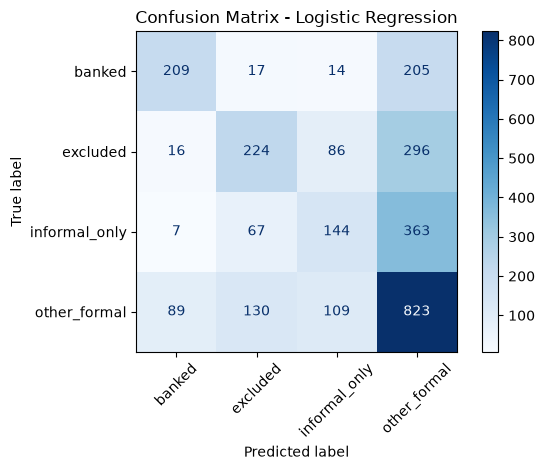

In [42]:
disp = ConfusionMatrixDisplay(c_matrix, display_labels=reg_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

## RandomForestClassifier

In [43]:
# Baseline Random Forest - default-style hyperparameters, no class_weight balancing applied
# since Random Forest is not sensitive to feature scale, we can use the same preprocessed data as for Logistic Regression
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_encoded, y_train)

y_pred_rf = rf.predict(X_test_encoded)

print(classification_report(y_test, y_pred_rf))

               precision    recall  f1-score   support

       banked       0.56      0.51      0.54       445
     excluded       0.40      0.35      0.37       622
informal_only       0.30      0.24      0.27       581
 other_formal       0.48      0.57      0.52      1151

     accuracy                           0.44      2799
    macro avg       0.43      0.42      0.42      2799
 weighted avg       0.44      0.44      0.44      2799



[[229  27  20 169]
 [ 22 216 130 254]
 [ 21 119 142 299]
 [139 178 178 656]]


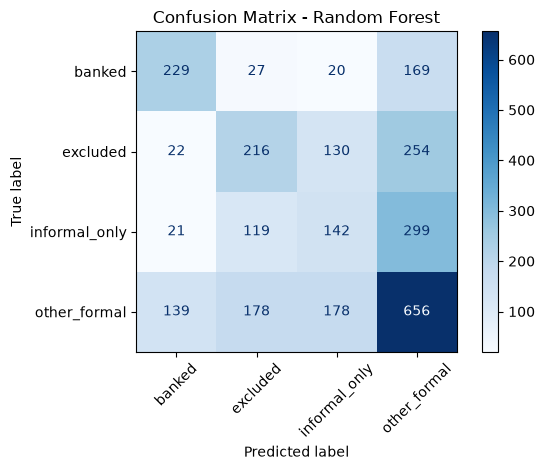

In [44]:
c_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print(c_matrix_rf)

disp = ConfusionMatrixDisplay(c_matrix_rf, display_labels=rf.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

our Random Forest scored 44% accuracy on the test set, which is actually lower than the Logistic Regression baseline of 50%     
next step is to perfom accuracy test just to check overfitting

In [45]:
train_acc = rf.score(X_train_encoded, y_train)
test_acc = rf.score(X_test_encoded, y_test)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

Train accuracy: 0.952
Test accuracy: 0.444


our is model scoring 95.2% on training data and only 44.4% on test data which confirm our suspicion of overfitting. our model memorizing patterns in our training data instead of learning general rules that apply to new people

## Clustering

In [46]:
g3a_cols = sorted([c for c in df.columns if c.startswith('g3a_')])
h3_cols = sorted([c for c in df.columns if c.startswith('h3_')])
cluster_cols = g3a_cols + h3_cols + ['l1']

# Converting every Yes/No column into 1/0 format to help us measure distance between points
X_cluster = df[cluster_cols].apply(lambda col: (col == 'Yes').astype(int))

print(X_cluster.shape)
print(X_cluster.isna().sum().sum())

(13994, 36)
0


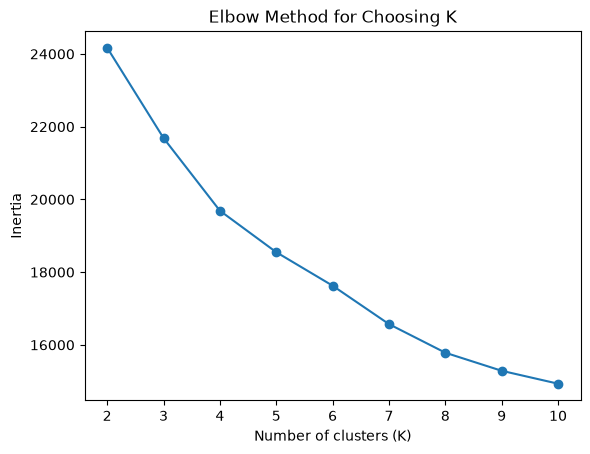

In [47]:
inertias = []
k_range = range(2, 11) # K range from 2 to 10 clusters, as we want to see how the inertia changes with different numbers of clusters
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Choosing K')
plt.show()

As our clusters (K) increase, inertia keeps dropping; from about 24,200 at K=2 down to about 14,900 at K=10 due to each additional cluster allowing people to be grouped with others more similar to them, so each person sits closer to their own group's center.  
Looking at where the drops get smaller, the biggest improvements happen between K=2 and K=4 (a fall of about 4,500), while after K=5 the curve flattens out, with each extra cluster only shaving off a small amount (around 500–1,000)

K=2: silhouette=0.264
K=3: silhouette=0.212
K=4: silhouette=0.244
K=5: silhouette=0.263
K=6: silhouette=0.281
K=7: silhouette=0.294


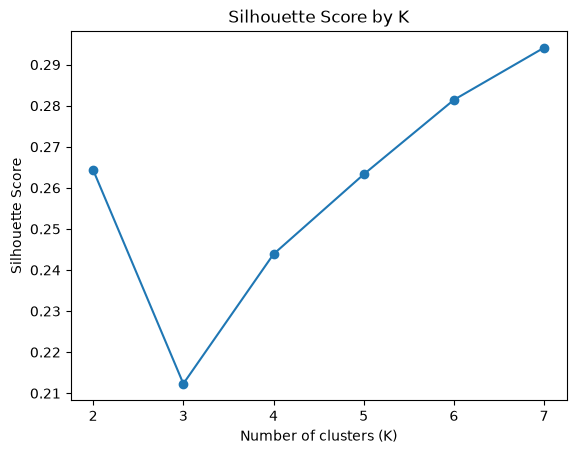

In [48]:
silhouette_scores = []
k_range = range(2, 8) 

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)
    print(f"K={k}: silhouette={score:.3f}")

plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.show()

As the number of clusters (K) increases from 2 to 7, the silhouette score doesn't move in one steady direction — it actually drops at K=3 (down to about 0.212), then climbs back up all the way to K=7 (about 0.294), due to K=3 producing poorly separated, overlapping groups, while adding more clusters after that seems to separate people better, at least so far.

K=2: silhouette=0.264
K=3: silhouette=0.212
K=4: silhouette=0.244
K=5: silhouette=0.263
K=6: silhouette=0.281
K=7: silhouette=0.294
K=8: silhouette=0.305
K=9: silhouette=0.317
K=10: silhouette=0.317
K=11: silhouette=0.329
K=12: silhouette=0.331
K=13: silhouette=0.349
K=14: silhouette=0.348
K=15: silhouette=0.362


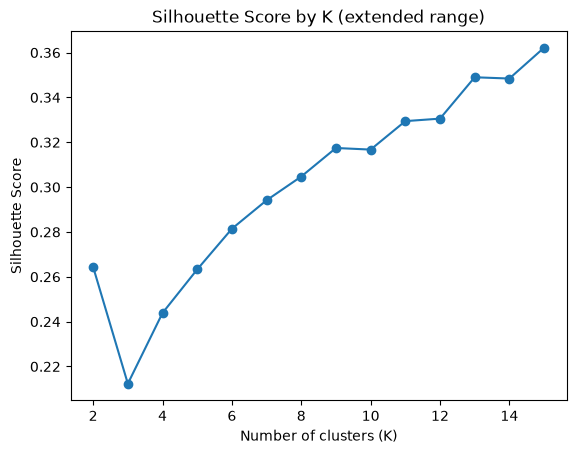

In [49]:
# Extending further up to 15 instead of stopping at 7
k_range_extended = range(2, 16)
silhouette_scores_extended = []

for k in k_range_extended:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores_extended.append(score)
    print(f"K={k}: silhouette={score:.3f}")

plt.plot(k_range_extended, silhouette_scores_extended, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K (extended range)')
plt.show()

when we only tested K=2 to K=7, the silhouette score was still rising at K=7 (0.294); the highest point we'd tested, but also the very edge of the test, so we couldn't tell if it would keep going up or turn back down. That's exactly why we extended the range to K=15.

In [50]:
from sklearn.cluster import KMeans

# We are going to use K-Means with K=5
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_cluster)

print(df['cluster'].value_counts().sort_index())

cluster
0    3685
1    1456
2    2349
3    2856
4    3648
Name: count, dtype: int64


In [51]:
# now we answer question like for each of our 36 columns, what % of people in that cluster answered "Yes"?
cluster_profile = X_cluster.copy()
cluster_profile['cluster'] = df['cluster']

profile_means = cluster_profile.groupby('cluster').mean().round(2)
profile_means

,g3a_01,g3a_02,g3a_03,g3a_04,g3a_05,g3a_06,g3a_07,g3a_08,g3a_09,g3a_10,...,h3_10,h3_11,h3_12,h3_13,h3_14,h3_15,h3_16,h3_17,h3_18,l1
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.14,0.02,0.15,0.00,0.06,0.0,0.00,0.09,0.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,1.00,0.04
1,0.09,0.04,0.25,0.00,0.16,0.0,0.01,0.17,0.0,0.01,...,0.04,0.05,0.02,0.29,0.07,1.00,0.0,0.02,0.00,0.94
2,0.25,0.08,0.29,0.01,0.12,0.0,0.03,0.18,0.0,0.01,...,0.05,0.03,0.02,0.28,0.09,0.32,0.0,0.05,0.00,0.13
3,0.13,0.04,0.16,0.00,0.13,0.0,0.01,0.20,0.0,0.01,...,0.01,0.01,0.00,0.04,0.01,0.00,0.0,0.02,0.78,0.88
4,0.09,0.03,0.20,0.00,0.15,0.0,0.01,0.20,0.0,0.01,...,0.02,0.02,0.00,0.07,0.01,0.00,0.0,0.01,0.00,0.88


In [56]:
# Rather than reading all 36 columns per cluster, show just each cluster's
# TOP 5 most common behaviors - this highlights what actually makes each
# group distinct, instead of drowning in numbers.
for c in sorted(df['cluster'].unique()):
    top5 = profile_means.loc[c].sort_values(ascending=False).head(5)
    for col, val in top5.items():
        print(f"  {labels.get(col, col)}: {val*100:.0f}%")

  h3. None borrowing: 100%
  g3a. Saving with - Do not save: 55%
  g3a. Saving through -  Mobile Money account: 15%
  g3a. Saving with - Commercial bank: 14%
  g3a. Saving with - Saving_Umurenge SACCO: 9%
  h3. Got goods in advance from a shop/store and had to pay back later: 100%
  g3a. Saving with - a group such as a coop, VSLA, tontine, ikibina: 97%
  L1. Do you belong to any informal financial groups?: 94%
  h3. Borrowed money from a group such as a co-op, VLSA, tontine, ikibina: 78%
  h3. Borrowed money from family/friends that you had to pay back: 29%
  h3. Got goods in advance from a shop/store and had to pay back later: 32%
  g3a. Saving through -  Mobile Money account: 29%
  h3. Borrowed money from family/friends that you had to pay back: 28%
  g3a. Saving with - Commercial bank: 25%
  g3a. Saving with - Do not save: 23%
  g3a. Saving with - a group such as a coop, VSLA, tontine, ikibina: 90%
  L1. Do you belong to any informal financial groups?: 88%
  h3. None borrowing: 78%


Simple version, cluster by cluster:

**Cluster 0**: All 100% don't borrow at all, and 55% don't save anywhere either. The rest save a little through mobile money, a bank, or a SACCO, but nothing stands out much.  

**Cluster 1**: All 100% get goods on credit from a shop, 97% save with an informal group (like ikibina), 94% belong to one, and 78% have borrowed from that group too.  

**Cluster 2**: No single behavior is very high — shop credit (32%), mobile money saving (29%), borrowing from family (28%), bank saving (25%) are all fairly close together.    

**Cluster 3**: 90% save with an informal group and 88% belong to one, but 78% don't borrow at all   

**Cluster 4**: 100% have borrowed from an informal group, and 94% save with one too.    

In [58]:
# does each behavior-based cluster line up with the financial-inclusion tiers we already know about?
pd.crosstab(df['cluster'], df['access_strand'], normalize='index').round(2) * 100

access_strand,banked,excluded,informal_only,other_formal
cluster,,,,
0,15.0,57.0,2.0,26.0
1,14.0,3.0,29.0,54.0
2,28.0,24.0,4.0,44.0
3,14.0,9.0,36.0,41.0
4,11.0,4.0,36.0,49.0


**Cluster 0**: 57% are excluded, way more than any other cluster.   

**Cluster 1**: Almost nobody is excluded (3%), and most (54%) are actually other_formal.    

**Cluster 2**: Has the highest banked rate of all (28%)     

**Cluster 3**: 36% are informal_only, the joint-highest of any cluster, matching what we'd expect from an informal-savings-focused group — but 41% are still other_formal.  

**Cluster 4**: Same pattern as Cluster 3: 36% informal_only, but 49% other_formal (the highest other_formal share of any cluster).  

In [59]:
%pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 8.8 MB/s  0:00:25m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 5.6 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 7.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.8/566.8 kB 5.4 MB/s  0:00:00
Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 

In [ ]:
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf #the library that will builds and trains the neural network

#Creates the encoder, then in one step: learns the 4 unique class names from y_train and converts them into numbers 0–3
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Applies that same mapping to the test labels
y_test_encoded = label_encoder.transform(y_test)
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

{'banked': 0, 'excluded': 1, 'informal_only': 2, 'other_formal': 3}


In [ ]:
# Starts building a network where data flows through layers one after another
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_encoded.shape[1],)), #how many numbers come in per person
    tf.keras.layers.Dense(64, activation='relu'), # 1st hidden layer with 64 neurons and ReLU activation
    tf.keras.layers.Dense(32, activation='relu'), # takes the 64 patterns from the first layer and combines them into 32 more refined, higher-level patterns
    tf.keras.layers.Dense(4, activation='softmax') #The output layer. Softmax turns the raw output into 4 probabilities that add up to 1
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# going through the entire training set 50 times (epochs=50), adjusting a bit each pass.
#batch_size=32: update the network after every 32 people rather than after all 11,195 at once or after every single one
# validation_split=0.2: secretly holds back 20% of training data
history = model.fit(X_train_encoded, y_train_encoded, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4509 - loss: 1.1990 - val_accuracy: 0.5194 - val_loss: 1.1040
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - accuracy: 0.5088 - loss: 1.0995 - val_accuracy: 0.5275 - val_loss: 1.0711
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step - accuracy: 0.5211 - loss: 1.0785 - val_accuracy: 0.5288 - val_loss: 1.0673
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step - accuracy: 0.5289 - loss: 1.0672 - val_accuracy: 0.5333 - val_loss: 1.0661
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - accuracy: 0.5315 - loss: 1.0560 - val_accuracy: 0.5364 - val_loss: 1.0660
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - accuracy: 0.5351 - loss: 1.0475 - val_accuracy: 0.5212 - val_loss: 1.0697
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - accuracy: 0.5418 - loss: 1.0370 - val_accuracy: 0.5297 - val_loss: 1.0657
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step - accuracy: 0.5468 - loss: 1.0261 - va

In [62]:
y_pred_probs = model.predict(X_test_encoded)
y_pred_nn_encoded = np.argmax(y_pred_probs, axis=1)
y_pred_nn = label_encoder.inverse_transform(y_pred_nn_encoded)

print(classification_report(y_test, y_pred_nn))

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step
               precision    recall  f1-score   support

       banked       0.52      0.51      0.51       445
     excluded       0.44      0.38      0.41       622
informal_only       0.34      0.29      0.32       581
 other_formal       0.50      0.58      0.54      1151

     accuracy                           0.46      2799
    macro avg       0.45      0.44      0.44      2799
 weighted avg       0.46      0.46      0.46      2799



banked: precision 0.52, recall 0.51; fairly balanced, similar territory to the other two models.        
excluded: precision 0.44, recall 0.38; still weak, still missing more than half of the truly excluded people (only 38% recall).      
informal_only: precision 0.34, recall 0.29; the weakest class again.            
other_formal: precision 0.50, recall 0.58; still benefits from being the largest class, but less extremely than Logistic Regression's 0.72 recall on the same class.

[[226  36  21 162]
 [ 35 236 117 234]
 [ 25 115 169 272]
 [150 150 185 666]]


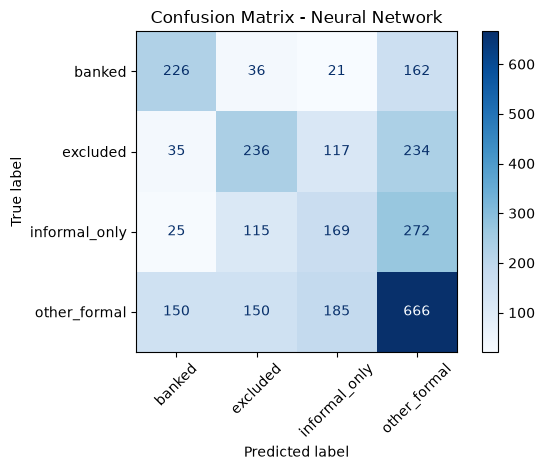

In [63]:
c_matrix_nn = confusion_matrix(y_test, y_pred_nn, labels=label_encoder.classes_)
print(c_matrix_nn)

disp = ConfusionMatrixDisplay(c_matrix_nn, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - Neural Network')
plt.tight_layout()
plt.show()

In [64]:
# Same overfitting check already run on Random Forest.
train_loss, train_acc = model.evaluate(X_train_encoded, y_train_encoded, verbose=0)
test_loss, test_acc = model.evaluate(X_test_encoded, y_test_encoded, verbose=0)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

Train accuracy: 0.656
Test accuracy: 0.463


In [65]:
train_acc_logreg = reg_model.score(X_train_encoded, y_train)
test_acc_logreg = reg_model.score(X_test_encoded, y_test)
print(f"Train accuracy: {train_acc_logreg:.3f}")
print(f"Test accuracy: {test_acc_logreg:.3f}")

Train accuracy: 0.523
Test accuracy: 0.500


#### COmparable report

In [66]:
nn_train_acc = train_acc
nn_test_acc = test_acc

# Build one row per model: test accuracy, macro F1 (pulled from classification_report's dict form
results = []

for name, y_pred, tr_acc, te_acc in [
    ('Logistic Regression', y_pred_logreg, reg_model.score(X_train_encoded, y_train), reg_model.score(X_test_encoded, y_test)),
    ('Random Forest', y_pred_rf, rf.score(X_train_encoded, y_train), rf.score(X_test_encoded, y_test)),
    ('Neural Network', y_pred_nn, nn_train_acc, nn_test_acc),
]:
    report = classification_report(y_test, y_pred, output_dict=True)
    macro_f1 = report['macro avg']['f1-score']
    results.append({
        'Model': name,
        'Test Accuracy': round(te_acc, 3),
        'Macro F1': round(macro_f1, 3),
        'Train Accuracy': round(tr_acc, 3),
        'Overfit Gap': round(tr_acc - te_acc, 3)
    })

comparison_table = pd.DataFrame(results)
comparison_table

,Model,Test Accuracy,Macro F1,Train Accuracy,Overfit Gap
0,Logistic Regression,0.500,0.464,0.523,0.022
1,Random Forest,0.444,0.424,0.952,0.508
2,Neural Network,0.463,0.443,0.656,0.193


Logistic Regression has the smallest overfit gap of 0.022 and the best test accuracy of 0.50.      
Random Forest has the largest overfit gap of0.508 and the worst test accuracy of 0.444.     
The Neural Network sits in the middle on both

##### improving Random Forest by changing it's parameters

In [ ]:
# max_depth: controls how many yes/no questions deep a single tree is allowed to ask before making a decision.
# min_simples_leaf: how many people must end up in a leaf
rf_improved = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42
)
rf_improved.fit(X_train_encoded, y_train)

train_acc = rf_improved.score(X_train_encoded, y_train)
test_acc = rf_improved.score(X_test_encoded, y_test)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")
print(f"Overfit gap: {train_acc - test_acc:.3f}")

print(classification_report(y_test, rf_improved.predict(X_test_encoded)))

Train accuracy: 0.533
Test accuracy: 0.496
Overfit gap: 0.037
               precision    recall  f1-score   support

       banked       0.68      0.45      0.54       445
     excluded       0.56      0.27      0.37       622
informal_only       0.41      0.06      0.10       581
 other_formal       0.46      0.86      0.60      1151

     accuracy                           0.50      2799
    macro avg       0.53      0.41      0.40      2799
 weighted avg       0.51      0.50      0.44      2799



setting max_depth tot 10 and minimum leaf size to 5 successfully addressed the severe overfitting observed in the baseline model, reducing the train–test accuracy gap from 0.508 to 0.037 but, examining the results reveals that bias toward majority class increased.

Banked: F1-score remained stable but precision rose from 0.56 to 0.68 while recall fell from 0.51 to 0.45.  

Excluded: The same pattern appears, F1 held constant (0.37), but precision increased (from 0.40 to 0.56) while recall dropped sharply (from 0.35 to 0.27).  

Informal_only: Recall collapsed from 0.24 to 0.06, and F1 fell from 0.27 to 0.10, despite a modest gain in precision (0.30 to 0.41).    

Other_formal: recall rose sharply from 0.57 to 0.86, driving its F1 up from 0.52 to 0.60, despite a slight decline in precision (0.48 to 0.46).

Limiting tree depth and leaf size reduces a Random Forest's capacity to carve out narrow, highly specific decision regions

In [68]:
# Same depth/leaf constraints as before but i added class_weight='balanced', it tells the model to treat mistakes on smaller classes
rf_balanced = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=5,
    class_weight='balanced', random_state=42
)
rf_balanced.fit(X_train_encoded, y_train)

y_pred_rf_balanced = rf_balanced.predict(X_test_encoded)
print(classification_report(y_test, y_pred_rf_balanced))

               precision    recall  f1-score   support

       banked       0.47      0.70      0.56       445
     excluded       0.45      0.42      0.43       622
informal_only       0.31      0.53      0.39       581
 other_formal       0.56      0.27      0.37      1151

     accuracy                           0.43      2799
    macro avg       0.45      0.48      0.44      2799
 weighted avg       0.47      0.43      0.42      2799



In [69]:
train_acc_balanced = rf_balanced.score(X_train_encoded, y_train)
test_acc_balanced = rf_balanced.score(X_test_encoded, y_test)
print(f"Train accuracy: {train_acc_balanced:.3f}")
print(f"Test accuracy: {test_acc_balanced:.3f}")
print(f"Overfit gap: {train_acc_balanced - test_acc_balanced:.3f}")

Train accuracy: 0.489
Test accuracy: 0.428
Overfit gap: 0.062


performance improved on the dimension each fix specifically targeted, but neither fix improved everything at once. Adding class balancing fixed class fairness, but accuracy decreased

All algorithm tested (Logistic Regression, Random Forest, and the Neural Network), Logistic Regression is the best-performing model on both test accuracy (0.500) and macro F1 (0.464)

Our best model correctly identified excluded people only about 42% of the time, which shows that education, location (urban vs. rural), and how a person earns income are real factors linked to financial exclusion in Rwanda, but they don't fully explain it. The simplest model (Logistic Regression) performed best overall, showing that a more complex model is not always a better model. From clustering, we also found that most people who use informal savings methods are still financially included through mobile money or similar services — the only group clearly matching real exclusion was people who neither save nor borrow through any method at all.